<a href="https://colab.research.google.com/github/mohadesehsotoudehnia/AI-home-works/blob/main/miniProject3%20/%20MP3_Part1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing Necessary Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Q1

[link text](https://)# Generating Samples

In [ ]:
def h(x):
    return np.exp(-np.pi * x**2) + x * np.sin(np.pi * x)

X_train = np.linspace(-1, 1, 300)

Y_train = h(X_train)

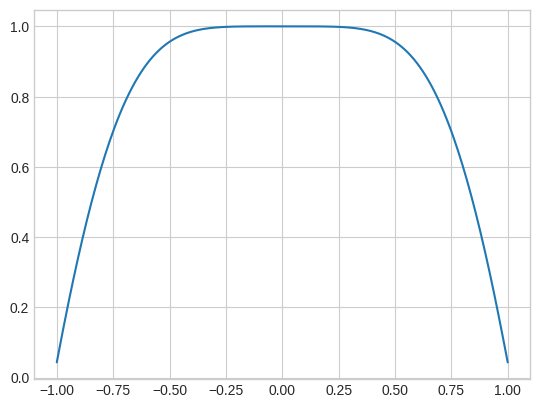

In [ ]:
plt.plot(X_train, Y_train)
plt.show()

# Define Triangular Membership Function

In [ ]:
# Define a triangular membership function
def triangular(x, a, b, c):
    return np.maximum(np.minimum((x - a) / (b - a), (c - x) / (c - b)), 0)

In [ ]:
# Number of membership functions
num_mfs = 20

# Centers of triangular MFs, evenly spaced in [-1, 1]
mf_centers = np.linspace(-1, 1, num_mfs)

# Width of each triangle (with overlap)
mf_width = (mf_centers[1] - mf_centers[0]) * 1.5

# Generate (a, b, c) for each triangle
mf_params = [(c - mf_width/2, c, c + mf_width/2) for c in mf_centers]

# Initialize rule outputs randomly within the range of y_data
rule_outputs = np.random.uniform(np.min(y_data), np.max(y_data), num_mfs)


# Define Fuzzy System and Defuzzification

In [ ]:
# Fuzzy inference using weighted average defuzzification
def fuzzy_inference(x, mf_params, rule_outputs):
    activations = np.array([triangular(x, *params) for params in mf_params])
    if np.sum(activations) == 0:
        return 0  # avoid division by zero
    return np.dot(activations, rule_outputs) / np.sum(activations)

# Training using GD

In [ ]:
lr = 0.01        # learning rate
epochs = 100     # number of training epochs

for epoch in range(epochs):
    total_loss = 0
    for xi, yi in zip(x_data, y_data):
        activations = np.array([triangular(xi, *params) for params in mf_params])
        y_pred = np.dot(activations, rule_outputs) / np.sum(activations)
        error = yi - y_pred
        total_loss += error**2
        # Update rule outputs based on gradient of the error
        rule_outputs += lr * error * activations / np.sum(activations)

# Evaluate the Final Fuzzy Model

In [ ]:
y_predicted = [fuzzy_inference(xi, mf_params, rule_outputs) for xi in x_data]

# Plot Result

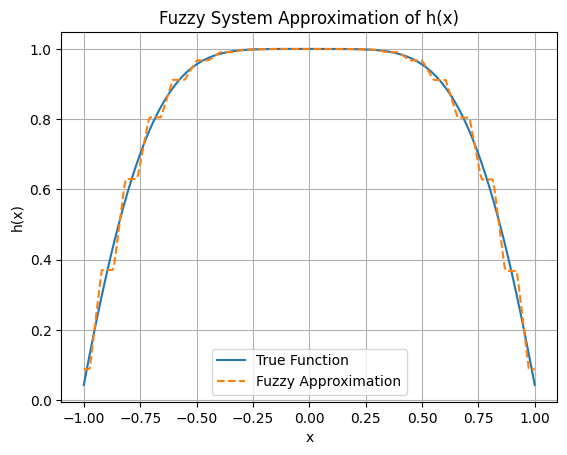

In [ ]:
plt.plot(x_data, y_data, label='True Function')
plt.plot(x_data, y_predicted, label='Fuzzy Approximation', linestyle='--')
plt.legend()
plt.title("Fuzzy System Approximation of h(x)")
plt.xlabel("x")
plt.ylabel("h(x)")
plt.grid(True)
plt.show()

# Q2

Starting training for 500 epochs...
Epoch 20/500, MSE: 0.0259
Epoch 40/500, MSE: 0.0109
Epoch 60/500, MSE: 0.0046
Epoch 80/500, MSE: 0.0019
Epoch 100/500, MSE: 0.0008
Epoch 120/500, MSE: 0.0005
Epoch 140/500, MSE: 0.0004
Epoch 160/500, MSE: 0.0003
Epoch 180/500, MSE: 0.0002
Epoch 200/500, MSE: 0.0002
Epoch 220/500, MSE: 0.0002
Epoch 240/500, MSE: 0.0002
Epoch 260/500, MSE: 0.0001
Epoch 280/500, MSE: 0.0001
Epoch 300/500, MSE: 0.0001
Epoch 320/500, MSE: 0.0001
Epoch 340/500, MSE: 0.0001
Epoch 360/500, MSE: 0.0001
Epoch 380/500, MSE: 0.0001
Epoch 400/500, MSE: 0.0001
Epoch 420/500, MSE: 0.0001
Epoch 440/500, MSE: 0.0001
Epoch 460/500, MSE: 0.0001
Epoch 480/500, MSE: 0.0001
Epoch 500/500, MSE: 0.0001
Training finished.

--- Evaluating with different defuzzifiers ---
Final MSE with Centroid (COA): 0.0589
Final MSE with Mean of Maximum (MOM): 0.0695

Accuracy goal (epsilon=0.1) corresponds to MSE < 0.0100
Centroid method did not reach the target accuracy. Try more epochs or rules.


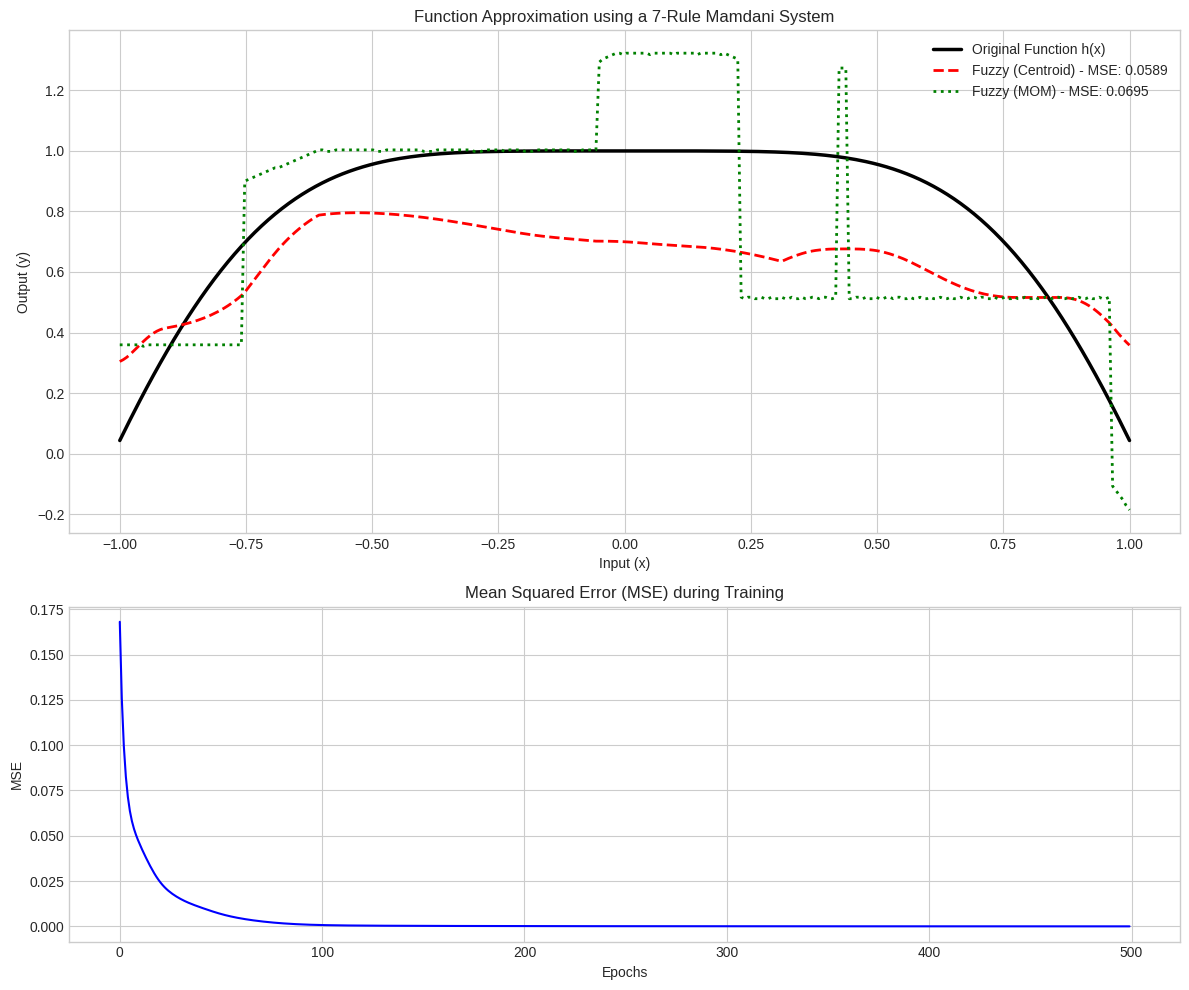

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Target Function and Data Generation ---
# --- ۱. تابع هدف و تولید داده ---

def h(x):
    """The target function to be approximated."""
    # This is the function we want our fuzzy system to learn.
    # h(x) = e^(-pi*x^2) + x * sin(pi*x)
    return np.exp(-np.pi * x**2) + x * np.sin(np.pi * x)

# Generate 300 data points uniformly in the range [-1, 1]
# ما ۳۰۰ نقطه داده ورودی (x) و خروجی (y) تولید می‌کنیم تا سیستم را با آن آموزش دهیم
x_data = np.linspace(-1, 1, 300)
y_data = h(x_data)

# --- 2. Fuzzy System Implementation ---
# --- ۲. پیاده‌سازی سیستم فازی ---

def gaussian_mf(x, center, sigma):
    """
    Gaussian Membership Function.
    This function calculates the degree of membership of an input 'x' to a fuzzy set
    represented by a Gaussian curve with a given 'center' and 'sigma' (width).
    """
    # این تابع، درجه عضویت یک ورودی را به یک مجموعه فازی با توزیع گوسی محاسبه می‌کند
    # سیگما نباید صفر باشد تا از تقسیم بر صفر جلوگیری شود
    if sigma == 0:
        return 1.0 if x == center else 0.0
    return np.exp(-0.5 * ((x - center) / sigma)**2)

class MamdaniFuzzySystem:
    """
    A Mamdani-type Fuzzy Inference System for function approximation.
    It uses Gaussian membership functions and is trained with Gradient Descent.
    """
    def __init__(self, num_rules, learning_rate=0.01):
        """
        Initializes the fuzzy system.
        - num_rules: The number of fuzzy rules (e.g., 7).
        - learning_rate: Step size for gradient descent updates.
        """
        self.num_rules = num_rules
        self.lr = learning_rate

        # Initialize parameters for input membership functions (MFs)
        # We have 'num_rules' Gaussian MFs for the input. Each has a center and a sigma.
        # Centers are initialized uniformly across the input range [-1, 1].
        # Sigmas are initialized to a constant value.
        # این پارامترها در حین آموزش بهینه خواهند شد
        self.input_centers = np.linspace(-1, 1, num_rules)
        self.input_sigmas = np.full(num_rules, 0.5) # A reasonable starting width

        # Initialize parameters for output membership functions (MFs)
        # For each rule, there is a corresponding output MF.
        # We initialize their centers based on the output data range.
        self.output_centers = np.linspace(np.min(y_data), np.max(y_data), num_rules)
        self.output_sigmas = np.full(num_rules, 0.5)

        # Create a discretized range for the output variable y for defuzzification
        # برای محاسبه مرکز ثقل، ما باید دامنه خروجی را به بخش‌های کوچکی تقسیم کنیم
        self.y_range = np.linspace(np.min(y_data) - 0.5, np.max(y_data) + 0.5, 200)

    def _get_firing_strengths(self, x):
        """Calculates the firing strength of each rule for a given input x."""
        # For a given input x, we calculate its membership degree to each of the input MFs.
        # This is the "fuzzification" step.
        # درجه آتش هر قانون برابر با درجه عضویت ورودی به تابع عضویت آن قانون است
        return np.array([gaussian_mf(x, c, s) for c, s in zip(self.input_centers, self.input_sigmas)])

    def _get_aggregated_output_mf(self, firing_strengths):
        """Aggregates the output of all rules into a single fuzzy set."""
        aggregated_mf = np.zeros_like(self.y_range)
        for i in range(self.num_rules):
            # For each rule, get the output MF
            rule_output_mf = gaussian_mf(self.y_range, self.output_centers[i], self.output_sigmas[i])
            # "Clip" the output MF using the rule's firing strength (Mamdani 'min' implication)
            # ما تابع عضویت خروجی را با درجه آتش آن "برش" می‌دهیم
            clipped_mf = np.minimum(firing_strengths[i], rule_output_mf)
            # Aggregate the result using 'max' operator
            # تمام خروجی‌های برش‌خورده را با هم ترکیب (تجمیع) می‌کنیم
            aggregated_mf = np.maximum(aggregated_mf, clipped_mf)
        return aggregated_mf

    def defuzzify_centroid(self, aggregated_mf):
        """
        Centroid of Area (COA) defuzzification.
        Calculates the crisp output value from the aggregated output MF.
        """
        # این متد، خروجی قطعی را با محاسبه مرکز ثقل سطح زیر نمودار تجمیع‌شده به دست می‌آورد
        numerator = np.sum(self.y_range * aggregated_mf)
        denominator = np.sum(aggregated_mf)

        # Avoid division by zero if the aggregated output is all zero
        if denominator == 0:
            return 0.0
        return numerator / denominator

    def defuzzify_mom(self, aggregated_mf):
        """
        Mean of Maximum (MOM) defuzzification.
        Finds the output value corresponding to the maximum membership degree.
        """
        # این متد، میانگین مقادیری که بیشترین درجه عضویت را دارند، به عنوان خروجی برمی‌گرداند
        max_membership = np.max(aggregated_mf)
        if max_membership == 0:
            return 0.0
        max_indices = np.where(aggregated_mf == max_membership)
        return np.mean(self.y_range[max_indices])

    def predict(self, x_inputs, method='centroid'):
        """Generates predictions for a set of inputs."""
        predictions = []
        for x in x_inputs:
            firing_strengths = self._get_firing_strengths(x)
            aggregated_mf = self._get_aggregated_output_mf(firing_strengths)

            if method == 'centroid':
                crisp_output = self.defuzzify_centroid(aggregated_mf)
            elif method == 'mom':
                crisp_output = self.defuzzify_mom(aggregated_mf)
            else:
                raise ValueError("Unknown defuzzification method.")

            predictions.append(crisp_output)
        return np.array(predictions)

    def train(self, x_data, y_data, epochs=200):
        """
        Trains the fuzzy system using gradient descent.
        NOTE: Deriving the true gradient for Mamdani with centroid is very complex.
        Here, we use a common and effective simplification inspired by ANFIS (Takagi-Sugeno models),
        which makes the training process feasible.
        """
        # توجه: محاسبه گرادیان واقعی برای سیستم ممدانی با غیرفازی‌ساز مرکز ثقل بسیار پیچیده است
        # ما در اینجا از یک روش ساده‌شده ولی موثر استفاده می‌کنیم که از مدل‌های ANFIS الهام گرفته شده است

        print(f"Starting training for {epochs} epochs...")
        self.errors = [] # To store error history for plotting

        for epoch in range(epochs):
            total_error = 0
            for x, y_d in zip(x_data, y_data):
                # --- Forward Pass (for training) ---
                w = self._get_firing_strengths(x)
                w_sum = np.sum(w)
                if w_sum == 0: continue # Skip if no rule fires

                # This is the simplified (TS-like) output for calculating gradients
                y_pred = np.sum(w * self.output_centers) / w_sum

                # --- Error Calculation ---
                error = y_pred - y_d
                total_error += error**2

                # --- Backward Pass (Gradient Calculation & Parameter Update) ---
                # Update output centers
                grad_c_out = error * (w / w_sum)
                self.output_centers -= self.lr * grad_c_out

                # Update input centers and sigmas
                common_term = error * (self.output_centers - y_pred) / w_sum
                grad_c_in = common_term * w * (x - self.input_centers) / (self.input_sigmas**2)
                grad_s_in = common_term * w * ((x - self.input_centers)**2) / (self.input_sigmas**3)

                self.input_centers -= self.lr * grad_c_in
                # Sigmas must remain positive
                self.input_sigmas = np.maximum(0.01, self.input_sigmas - self.lr * grad_s_in)


            # Store and print error for this epoch
            mse = total_error / len(x_data)
            self.errors.append(mse)
            if (epoch + 1) % 20 == 0:
                print(f"Epoch {epoch + 1}/{epochs}, MSE: {mse:.4f}")

        print("Training finished.")

# --- 3. Main Execution and Visualization ---
# --- ۳. اجرای اصلی و مصورسازی ---
if __name__ == "__main__":
    # Define system parameters
    # شما می‌توانید تعداد قوانین، نرخ یادگیری و دوره‌های آموزش را تغییر دهید
    NUM_RULES = 7 # At least 5-9 rules are needed. 7 is a good start.
    LEARNING_RATE = 0.005
    EPOCHS = 500

    # Create and train the fuzzy system
    fuzzy_system = MamdaniFuzzySystem(num_rules=NUM_RULES, learning_rate=LEARNING_RATE)
    fuzzy_system.train(x_data, y_data, epochs=EPOCHS)

    # --- Evaluation and Comparison ---
    # After training, we get the final predictions using different defuzzifiers
    # پس از آموزش، خروجی نهایی را با روش‌های مختلف غیرفازی‌سازی به دست می‌آوریم
    print("\n--- Evaluating with different defuzzifiers ---")

    # Using Centroid (COA)
    y_pred_centroid = fuzzy_system.predict(x_data, method='centroid')
    mse_centroid = np.mean((y_pred_centroid - y_data)**2)
    print(f"Final MSE with Centroid (COA): {mse_centroid:.4f}")

    # Using Mean of Maximum (MOM)
    y_pred_mom = fuzzy_system.predict(x_data, method='mom')
    mse_mom = np.mean((y_pred_mom - y_data)**2)
    print(f"Final MSE with Mean of Maximum (MOM): {mse_mom:.4f}")

    # The accuracy goal was epsilon = 0.1, which corresponds to an MSE of 0.1^2 = 0.01
    print(f"\nAccuracy goal (epsilon=0.1) corresponds to MSE < {0.1**2:.4f}")
    if mse_centroid < 0.01:
        print("Centroid method achieved the desired accuracy!")
    else:
        print("Centroid method did not reach the target accuracy. Try more epochs or rules.")

    # --- Plotting Results ---
    # نمودارها به ما کمک می‌کنند نتایج را به صورت بصری تحلیل کنیم
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [3, 2]})

    # Plot 1: Function Approximation
    ax1.plot(x_data, y_data, 'k-', linewidth=2.5, label='Original Function h(x)')
    ax1.plot(x_data, y_pred_centroid, 'r--', linewidth=2, label=f'Fuzzy (Centroid) - MSE: {mse_centroid:.4f}')
    ax1.plot(x_data, y_pred_mom, 'g:', linewidth=2, label=f'Fuzzy (MOM) - MSE: {mse_mom:.4f}')
    ax1.set_title(f'Function Approximation using a {NUM_RULES}-Rule Mamdani System')
    ax1.set_xlabel('Input (x)')
    ax1.set_ylabel('Output (y)')
    ax1.legend()
    ax1.grid(True)

    # Plot 2: Training Error (MSE)
    ax2.plot(range(EPOCHS), fuzzy_system.errors, 'b-')
    ax2.set_title('Mean Squared Error (MSE) during Training')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('MSE')
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

In [ ]:
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import linkage
####################
# Load a dataset: columns are (Environ) label and
# multiple (obs)
def getData():
  environs = pd.read_csv( 'radardata.csv' )
  environs = environs.set_index('Environ')
  return environs
####################
# Efficient method to replace NaNs with the mu
# for that environ/obs
def cleanNaNs(df):
  newDF = pd.DataFrame()
  environs = np.unique( df.index )
  for environ in environs:
    # Instances for this environ
    instances = df.loc[ df.index == environ ]
    # Only replace NaN in columns with NaN values
  nanCols = instances.isnull().any(axis=0)
  for i in instances.columns[nanCols]:
    # Replace NaN in this col with mean of
    # other vals
    instances[i].fillna( instances[i].mean(),
    inplace=True )
    newDF = newDF.append(instances)
  return newDF
####################
if __name__ == '__main__':
  df = getData()
df = cleanNaNs(df)
nEnvirons = len(np.unique( df.index ))
fig,ax = plt.subplots(figsize=(12,8))
Z = linkage(df,method='ward')
dendrogram(Z,truncate_mode='lastp',
p=nEnvirons,orientation='left')
fig.tight_layout()
plt.savefig('dendrogram.pdf')
plt.close()

FileNotFoundError: [Errno 2] No such file or directory: 'radardata.csv'